# Додаткове завдання до модуля 4: візуалізація даних.
В цьому ДЗ ми будемо багато працювати не тільки з візуалізаціями, а і з функціоналом pandas, адже візуалізація даних - це частина аналізу даних та працює спільно з агрегацією та фільтрацією наших даних. До того ж перед тим, як аналізувати дані, їх треба почистити. Чим ми і займемось.  

0.Імпортуйте бібліотеки matplotlib.pyplot, seaborn та pandas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Набір даних Taxis

Використовуючи метод з бібліотеки `seaborn` `load_dataset` ми завантажимо перший набір даних для аналізу. Завантажимо дані так, бо це зручно + аби ви знали, що є і така можливість знайти собі набір даних для експериментів.  
Набір даних містить поїздки таксі у Нью Йорку у 2019 році. Детальний опис на [сайті](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).  

Які колонки мість набір даних:  
- `pickup` - час початку поїздки  
- `dropoff` - час закінчення поїздки  
- `passengers` - кількість пасажирів у поїздці  
- `distance` - відстань поіздки  
- `fare` - базова плата за поїздку  
- `tip` - розмір чайових  
- `tolls` - плата за платні дороги (за це також платить пасажир)  
- `total` - сумарна плата за поїздку  
- `color` - колір авто, яке здійснювало поїздку  
- `payment` - метод оплати  
- `pickup_zone` - зона, у якій почалась поїздка  
- `dropoff_zone` - зона, у якій закінчилась поїздка  
- `pickup_borough` - район, у якому почалась поїздка  
- `dropoff_borough` - район, у якому закінчилась поїздка  

Назви ознак здебільшого говорять самі за себе. Слово borough перекладається з англійської як "район".

Ми будемо працювати сами з тим шматочком даних, які наявні в seaborn.  
Переглянути всі набори даних з seaborn можна [тут](https://github.com/mwaskom/seaborn-data).

Спершу - завантажуємо дані - просто виконайте клітинку нижче.

In [2]:
df_taxi = sns.load_dataset('taxis')

1.Виведіть
- перші 3 записи з набору даних
- типи даних в наборі даних df_taxi
- розміри набору даних

In [3]:
display(df_taxi.head(3))

print()

display(df_taxi.dtypes)

print()

print(df_taxi.shape)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan


pickup             datetime64[us]
dropoff            datetime64[us]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                         str
payment                       str
pickup_zone                   str
dropoff_zone                  str
pickup_borough                str
dropoff_borough               str
dtype: object


(6433, 14)


Очікуваний результат (можна вивести в окремих клітинках):

![](https://drive.google.com/uc?export=view&id=1rsgJvFEdXwGDTVl3CyyRL2ao8rzR_8P2)

2.Перевіримо, чи є в цьому наборі даних пропущені значення. Для цього можемо вивести кількість пропущених значень в кожній колонці наступним чином (це надзвичайно корисна команда, запамʼятайте її):

In [4]:
df_taxi.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Цікаво, чому дані відсутні? Відповідь на це питання нам дасть розуміння, чи можна такі дані видалити, чи можливо їх треба якось заповнити. Виведіть на екран ті рядки, де колонка, яка має найбільше пропущених значень (або одна з тих, що має максимальну кількість пропущених), має пропущені значення.
Подивіться на результат і напишіть свої думки щодо питань:
- чому на ваш погляд в цих рядках є відстуні дані в кількох колонках? Чому ви так думаєте?
- чому на ваш погляд є рядки з distance==0, а total!=0? Як ви до цього прйишли?
Відповідь просто текстом. Можна використовувати будь-які допоміжні операції над датасетом чи джерела, які допоможуть вам відповісти на ці питання. Якщо щось використовуєте, то це треба зазначити у відповіді.  

Ваша відповідь тут - це 70% виконання цього завдання.

In [5]:
df_taxi[df_taxi['dropoff_zone'].isna()]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.00,80.0,20.08,0.00,100.38,yellow,credit card,NaN,NaN,NaN,NaN
622,2019-03-12 19:52:36,2019-03-12 19:52:55,3,0.00,120.0,33.20,12.50,166.00,yellow,credit card,NaN,NaN,NaN,NaN
711,2019-03-21 17:39:50,2019-03-21 18:12:54,2,1.74,17.0,4.26,0.00,25.56,yellow,credit card,Midtown East,NaN,Manhattan,NaN
739,2019-03-14 00:09:17,2019-03-14 00:09:21,1,0.03,2.5,0.00,0.00,3.80,yellow,cash,Upper East Side South,NaN,Manhattan,NaN
970,2019-03-29 00:02:00,2019-03-29 00:02:05,2,0.00,45.0,5.00,0.00,50.30,yellow,credit card,NaN,NaN,NaN,NaN
1108,2019-03-10 09:33:13,2019-03-10 09:52:04,1,13.40,52.0,11.70,5.76,70.26,yellow,credit card,NaN,NaN,NaN,NaN
1112,2019-03-12 19:09:23,2019-03-12 19:20:46,1,0.90,8.5,1.92,0.00,14.72,yellow,credit card,Times Sq/Theatre District,NaN,Manhattan,NaN
1230,2019-03-29 07:52:46,2019-03-29 08:02:40,1,0.90,5.5,1.76,0.00,10.56,yellow,credit card,Yorkville East,NaN,Manhattan,NaN
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,1,0.00,72.0,0.00,0.00,72.00,yellow,NaN,East New York,NaN,Brooklyn,NaN
1787,2019-03-28 06:58:57,2019-03-28 07:18:10,1,6.32,20.5,4.26,0.00,25.56,yellow,credit card,Manhattan Valley,NaN,Manhattan,NaN


Найбільше пропущених значень є в колонках `dropoff_zone` та `dropoff_borough`.  
Також у частині цих рядків відсутні `pickup_zone` та `pickup_borough`.

На мою думку, пропуски пов’язані з тим, що для деяких поїздок не вдалося визначити географічну зону або район початку/завершення поїздки. Оскільки `borough` визначається на основі `zone`, то якщо відсутня зона, часто буде відсутній і відповідний район.

У рядках, де `distance = 0`, але `total != 0`, поїздка могла бути скасована, некоректно записана або мати мінімальну/базову плату. Також у суму `total` можуть входити не лише відстань, а й базова плата, чайові, платні дороги або інші комісії. Тому навіть при нульовій відстані загальна сума може бути більшою за 0.

Такі рядки не варто одразу видаляти. Спочатку їх потрібно окремо проаналізувати, бо частина з них може бути реальними поїздками, а частина — помилковими або скасованими.

In [6]:
df_taxi[
    (df_taxi['dropoff_zone'].isna()) & 
    (df_taxi['distance'] == 0) & 
    (df_taxi['total'] != 0)
]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.0,80.0,20.08,0.0,100.38,yellow,credit card,NaN,NaN,NaN,NaN
622,2019-03-12 19:52:36,2019-03-12 19:52:55,3,0.0,120.0,33.20,12.5,166.00,yellow,credit card,NaN,NaN,NaN,NaN
970,2019-03-29 00:02:00,2019-03-29 00:02:05,2,0.0,45.0,5.00,0.0,50.30,yellow,credit card,NaN,NaN,NaN,NaN
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,1,0.0,72.0,0.00,0.0,72.00,yellow,NaN,East New York,NaN,Brooklyn,NaN
2742,2019-03-23 06:20:27,2019-03-23 06:20:59,1,0.0,55.0,0.00,0.0,55.80,yellow,credit card,NaN,NaN,NaN,NaN
3644,2019-03-19 23:30:50,2019-03-19 23:32:33,2,0.0,103.0,20.65,0.0,123.95,yellow,credit card,NaN,NaN,NaN,NaN
3889,2019-03-30 06:42:55,2019-03-30 06:43:00,1,0.0,2.5,0.00,0.0,3.30,yellow,cash,NaN,NaN,NaN,NaN
4118,2019-03-15 14:01:54,2019-03-15 14:01:59,1,0.0,25.0,5.06,0.0,30.36,yellow,credit card,NaN,NaN,NaN,NaN
5493,2019-03-06 12:14:00,2019-03-06 12:14:00,1,0.0,10.0,0.00,0.0,10.00,green,credit card,NaN,NaN,NaN,NaN
5624,2019-03-11 14:04:50,2019-03-11 14:04:50,1,0.0,2.5,0.00,0.0,3.30,green,cash,NaN,NaN,NaN,NaN


Після додаткової перевірки видно, що серед рядків із пропущеним `dropoff_zone` є поїздки, де `distance = 0`, але `total > 0`. У таких рядках часто також відсутні географічні дані по зоні/району, а час початку і завершення поїздки дуже близький або однаковий.

На мою думку, це може свідчити про скасовані, неповні або некоректно записані поїздки. При цьому `total` не дорівнює нулю, бо в суму могли потрапити базова плата, комісія, чайові або інші нарахування, які не залежать напряму від відстані.

3.Заповнимо пусті значення. Оскільки всі колонки набору даних мають пропущені значення в рядках з типом даних рядок, заповнимо пропущені значення рядком `NA`.
Створіть набір даних `df_taxi_clean`, який містить дані `df_taxi` із заповненими пропущеними значеннями у всіх колонках (де ті значення відсутні) значенням `NA`.

**УВАГА!** Надалі в роботі треба використовувати `df_taxi_clean`, ми ж його і створили для того, аби далі ним користуватись :)

In [7]:
df_taxi_clean = df_taxi.copy()
df_taxi_clean = df_taxi_clean.fillna('NA')

Після виконання завдання запустіть наступну клітинку:

In [8]:
df_taxi_clean.isna().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=1G5_k_jmtNFFRdn7Kcw_fEoJyrkTeOGP4)

4.Хочеться подивитись на дані у динаміці. Перетворіть колонку `pickup` набору даних `df_taxi_clean` (нам нема чого працювати з "брудними" даними, якщо ми їх вже почистили, але хай будуть в окремій змінній про всяк випадок) у формат `datetime64[ns]`.
Якщо у Вас при завантаженні набору даних колонка `pickup`- вже в форматі `datetime64[ns]` - можете пропустити це завдання, або спробувати все ж таки написат функцію для трансформації.

Результат перетворення збережіть в тій самій колонці `pickup`.

In [9]:
df_taxi_clean['pickup']

0      2019-03-23 20:21:09
1      2019-03-04 16:11:55
2      2019-03-27 17:53:01
3      2019-03-10 01:23:59
4      2019-03-30 13:27:42
               ...        
6428   2019-03-31 09:51:53
6429   2019-03-31 17:38:00
6430   2019-03-23 22:55:18
6431   2019-03-04 10:09:25
6432   2019-03-13 19:31:22
Name: pickup, Length: 6433, dtype: datetime64[us]

In [10]:
# формат був вірний, але напишемо формулу

df_taxi_clean['pickup'] = df_taxi_clean['pickup'].astype('datetime64[ns]')

Після виконання завдання запустіть наступну клітинку:

In [11]:
df_taxi_clean.pickup.head(3)

0   2019-03-23 20:21:09
1   2019-03-04 16:11:55
2   2019-03-27 17:53:01
Name: pickup, dtype: datetime64[ns]

Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=106hQKdEhLV3OIeFsP8yvXLo0cKk6Jmqo)

5.У нас колонка pickup зараз мість дані у форматі дата-час. Пропоную прибрати час і зробити аналітику по дням. Для цього виконайте клітинку нижче:

In [12]:
df_taxi_clean['pickup_day'] = df_taxi_clean['pickup'].dt.floor('D')

А тепер згрупуйте дані по pickup_day та виведіть графік сумарних платежів по дням. УВАГА! Якщо хочете отримати підписи по осі ОХ як на прикладі, то графік необхідно будувати через `df.plot(...)`. Якщо у Вас будуть інші підписи осі ОХ - це ОК.

Після виведення графіку скажіть, чи бачите щось дивне на ньому? Важливо написати відповідь в цьому завданні словами.

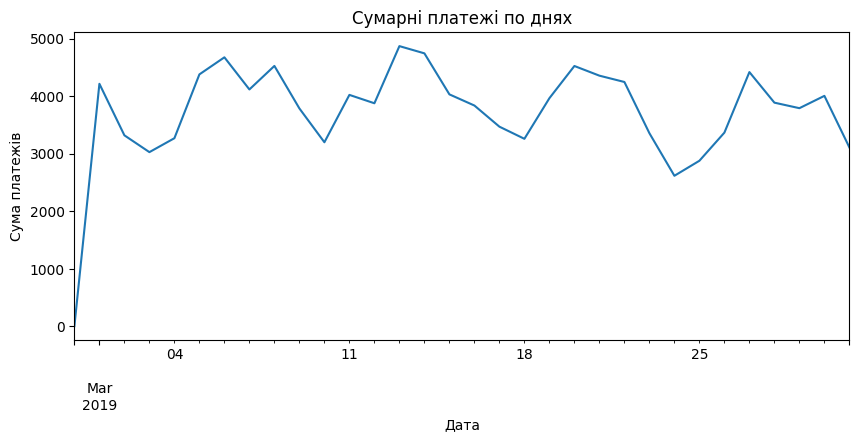

In [13]:
df_taxi_clean.groupby('pickup_day')['total'].sum().plot(figsize=(10, 4))

plt.title('Сумарні платежі по днях')
plt.xlabel('Дата')
plt.ylabel('Сума платежів')
plt.show()

Приклад очікуваного графіку:

![](https://drive.google.com/uc?export=view&id=1t8yb_NNO2tfwDFDrBNl0BLJoYB0BsUK_)

На графіку видно, що сума платежів по днях змінюється нерівномірно: є дні з більшими та меншими сумарними платежами. Це може бути пов’язано з різною кількістю поїздок у різні дні або з наявністю окремих поїздок з високою вартістю.

Також на початку графіка видно аномально низьке значення. Ймовірно, це пов’язано з тим, що за дату 2019-02-28 є лише один рядок, який випадково потрапив до набору даних.

6.Виведіть кількість рядків для кожного pickup_day.

In [14]:
df_taxi_clean['pickup_day'].value_counts().sort_index()

pickup_day
2019-02-28      1
2019-03-01    241
2019-03-02    198
2019-03-03    169
2019-03-04    171
2019-03-05    228
2019-03-06    257
2019-03-07    218
2019-03-08    235
2019-03-09    204
2019-03-10    185
2019-03-11    209
2019-03-12    218
2019-03-13    244
2019-03-14    260
2019-03-15    201
2019-03-16    220
2019-03-17    178
2019-03-18    173
2019-03-19    201
2019-03-20    233
2019-03-21    221
2019-03-22    229
2019-03-23    209
2019-03-24    149
2019-03-25    155
2019-03-26    178
2019-03-27    232
2019-03-28    205
2019-03-29    209
2019-03-30    215
2019-03-31    187
Name: count, dtype: int64

Маєте побачити, що для дати 2019-02-28 є тільки один рядок. Це запис, який, схоже, потрапив сюди випадково, видаліть з набору даних df_taxi_clean рядок, що містить pickup_day рівний 2019-02-28. Та знову виведіть графік сумарних платежів по pickup_day.

In [15]:
df_taxi_clean = df_taxi_clean[df_taxi_clean['pickup_day'] != '2019-02-28']
df_taxi_clean.groupby('pickup_day').size()

pickup_day
2019-03-01    241
2019-03-02    198
2019-03-03    169
2019-03-04    171
2019-03-05    228
2019-03-06    257
2019-03-07    218
2019-03-08    235
2019-03-09    204
2019-03-10    185
2019-03-11    209
2019-03-12    218
2019-03-13    244
2019-03-14    260
2019-03-15    201
2019-03-16    220
2019-03-17    178
2019-03-18    173
2019-03-19    201
2019-03-20    233
2019-03-21    221
2019-03-22    229
2019-03-23    209
2019-03-24    149
2019-03-25    155
2019-03-26    178
2019-03-27    232
2019-03-28    205
2019-03-29    209
2019-03-30    215
2019-03-31    187
dtype: int64

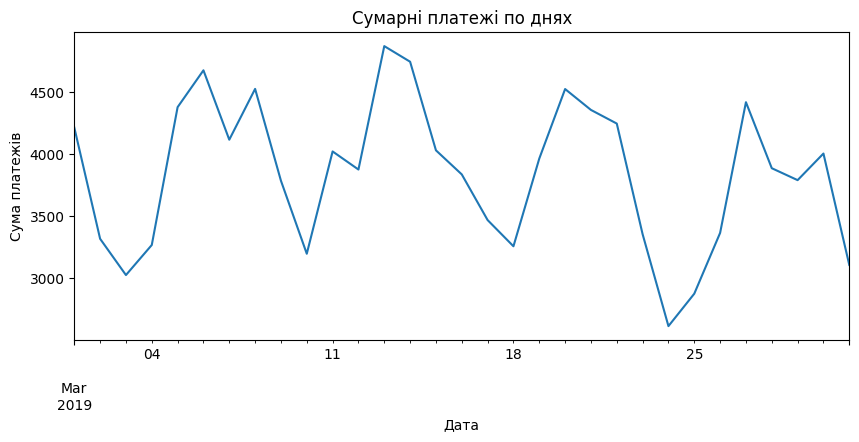

In [16]:
df_taxi_clean.groupby('pickup_day')['total'].sum().plot(figsize=(10, 4))

plt.title('Сумарні платежі по днях')
plt.xlabel('Дата')
plt.ylabel('Сума платежів')
plt.show()

Очікуваний графік:

![](https://drive.google.com/uc?export=view&id=1RfSjsgr5991dlz5bVbfXl8tCnUZhFJ8B)

7.Давайте подивимось на динаміку сумарних платежів по районам. Для цього сформуйте на основі `df_taxi_clean` зводну таблицю, де рядками є `pickup_day`, колонками `pickup_borough`, а значенням - сума платежів. Запишіть зводну таблицю в змінну `borough_pivot`. Наостанок, вилучіть колонку зі значенням `pickup_borough` рівним `NA` - уявімо, що ці дані нас не цікавлять.

In [17]:
borough_pivot = df_taxi_clean.pivot_table(
    index='pickup_day',
    columns='pickup_borough',
    values='total',
    aggfunc='sum'
)

borough_pivot = borough_pivot.drop(columns='NA', errors='ignore')

borough_pivot

pickup_borough,Bronx,Brooklyn,Manhattan,Queens
pickup_day,,,,
2019-03-01,123.42,353.05,3169.47,553.29
2019-03-02,NaN,146.56,2716.33,456.13
2019-03-03,80.75,407.06,2100.23,428.73
2019-03-04,92.00,188.73,2026.17,962.18
2019-03-05,98.16,558.40,2981.26,739.56
2019-03-06,130.65,198.53,3501.07,833.36
2019-03-07,NaN,440.75,3087.82,587.13
2019-03-08,79.20,237.47,3408.85,780.34
2019-03-09,80.22,187.88,2967.71,511.73


Далі запустіть наступну клітинку та дайте відповідь на питання, в якому районі найчастіше найбільша сума денних платежів за поїздки на таксі?   
До речі, також рекомендую спробувати запустити команду `borough_pivot.plot()` та зрозуміти, навіщо нам тут частина `fillna(0)`.

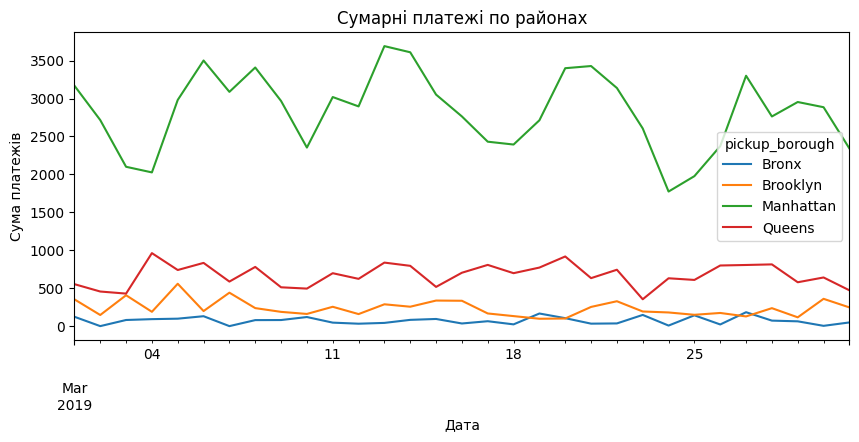

In [18]:
borough_pivot.fillna(0).plot(figsize=(10, 4))

plt.title('Сумарні платежі по районах')
plt.xlabel('Дата')
plt.ylabel('Сума платежів')
plt.show()

Очікуваний графік :

![](https://drive.google.com/uc?export=view&id=1zhLnMdPCg54j2yzU1hRWv6wseSNPT1Oy)

8.Виведіть будь-яким способом гістограми суми денних платежів за поїздки по кожному з районів. Має бути 4 гістограми, на 4ох різних фігурах, або на одній.   

`Підказка:` Найпростіше це буде зробити, використавши `borough_pivot` та побудову графіку через `<назва датафрейму>.<назва графіку>()` - тобто методом датафрейму з пандаса. Але графік можна побудувати також використовуючи цикл. Для тих, хто хоче потренуватись, рекомендую зробити обома способами.

Пограйтесь з кількістю бінів. Яка кількість бінів на ваш погляд тут є вдалою? Чому?

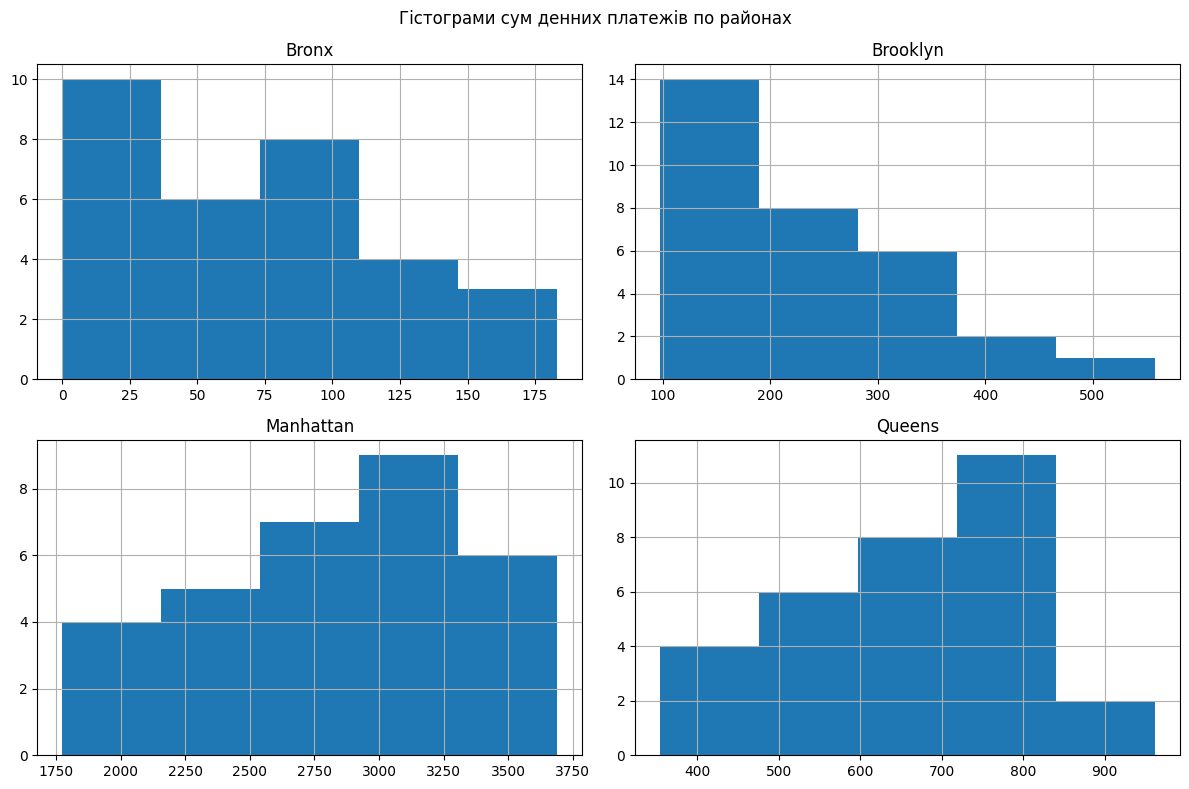

In [19]:
borough_pivot.fillna(0).hist(bins=5, figsize=(12, 8))

plt.suptitle('Гістограми сум денних платежів по районах')
plt.tight_layout()
plt.show()

Для побудови гістограм я використала 5 бінів. На мій погляд, така кількість є вдалою, бо даних не дуже багато, тому графіки залишаються читабельними і дозволяють побачити загальний розподіл сум денних платежів по кожному району.

З гістограм видно, що суми денних платежів суттєво відрізняються між районами. Найбільші значення спостерігаються в Manhattan, а найменші — у Bronx.

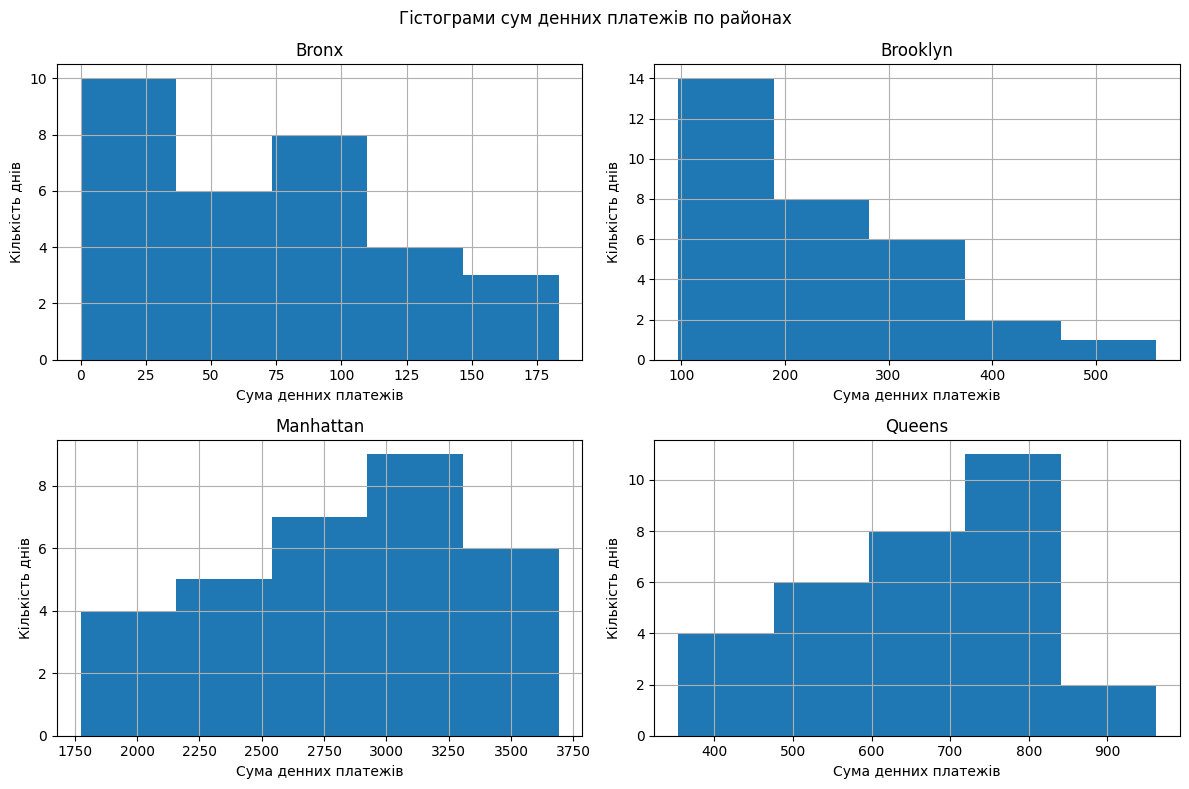

In [20]:
# подубова гістограми через цикл

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for i, borough in enumerate(borough_pivot.columns):
    borough_pivot[borough].fillna(0).hist(bins=5, ax=axes[i])
    axes[i].set_title(borough)
    axes[i].set_xlabel('Сума денних платежів')
    axes[i].set_ylabel('Кількість днів')

fig.suptitle('Гістограми сум денних платежів по районах')
plt.tight_layout()
plt.show()

Приклад одного з правильних виконань завдання:

![](https://drive.google.com/uc?export=view&id=1AfkIgwUAtaDiYoiK6NBOqCHBdUngRz4z)

9.Бачимо, що на окремих гістограмах у нас різні діапазони чеків. Припустимо, нам хочеться порівняти розподіли денних сум платежів по районам. Давайте для цього виведемо 4 гістограми на одній фігурі. Вони звісно ж мають бути різного кольору і напівпрозорими для комфортного перегляду. Створіть гістограму максимально близьку до тої, що надана в очікуваному результаті.
`Підказка:` ця візуалізація створена з допомогою pandas plotting.

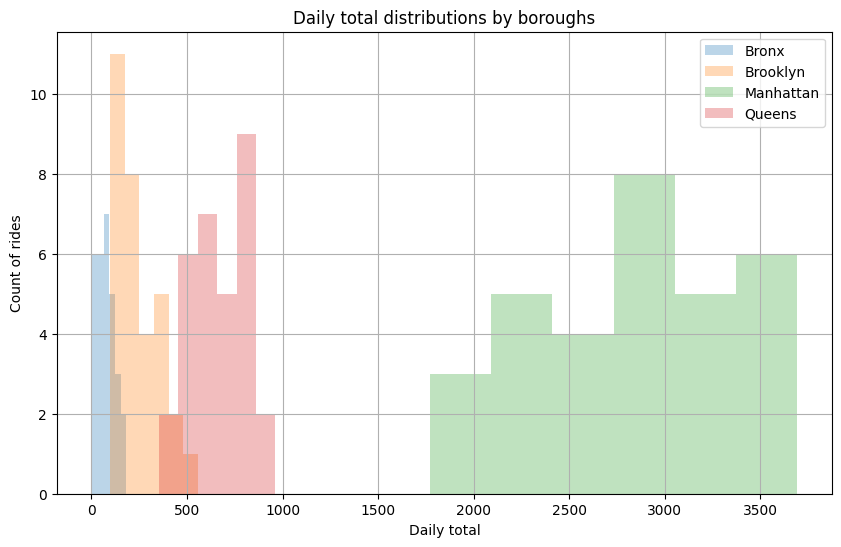

In [21]:
ax = None

for borough in borough_pivot.columns:
    ax = borough_pivot[borough].dropna().plot.hist(
        bins=6,
        alpha=0.3,
        figsize=(10, 6),
        label=borough,
        ax=ax
    )

plt.title('Daily total distributions by boroughs')
plt.xlabel('Daily total')
plt.ylabel('Count of rides')
plt.legend()
plt.grid()
plt.show()

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1J5PCLfVovNqeGxeeBGFUSS1Kqh6-UnwR)

А ось приклад, як можна було сформувати щось подібне з допомогою функціоналу seaborn. Як на мене візуалізація за замовчанням не є зручною для розуміння.  

`Опціональне завдання`: Пограйтесь з налаштуваннями і пошукайте варіант, за якого візуалізація розподілу суми денних платежів через seaborn є на ваш погляд зручною для аналізу.

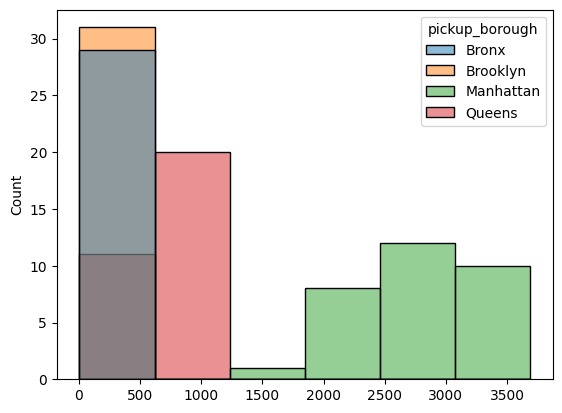

In [22]:
sns.histplot(data=borough_pivot, bins=6);

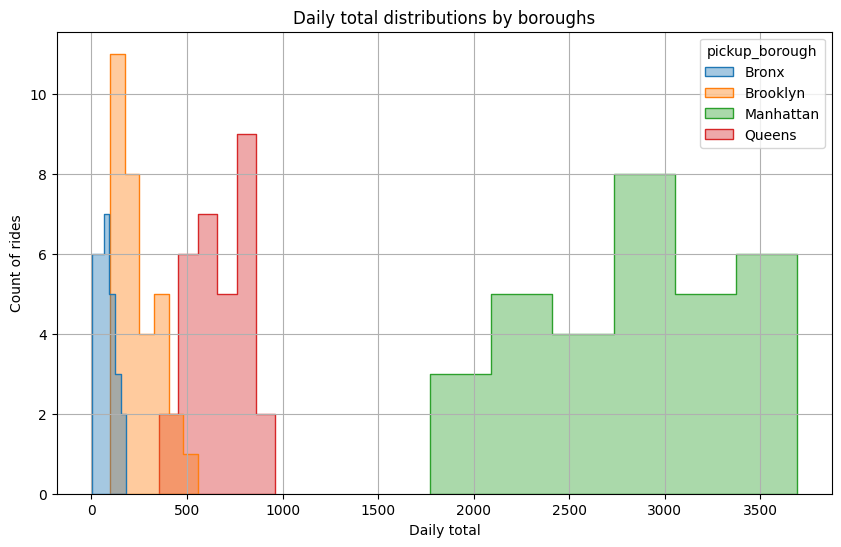

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=borough_pivot,
    bins=6,
    alpha=0.4,
    multiple='layer',
    common_bins=False,
    element='step'
)

plt.title('Daily total distributions by boroughs')
plt.xlabel('Daily total')
plt.ylabel('Count of rides')
plt.grid()
plt.show()

Для побудови гістограми через seaborn я використала 6 бінів, прозорість `alpha=0.4` та параметр `element='step'`, щоб розподіли по районах було зручніше порівнювати на одному графіку. Видно, що Manhattan має значно вищі денні суми платежів, тоді як Bronx та Brooklyn зосереджені в нижчому діапазоні.

10.З допомогою seaborn виведіть гістограми суми щомісячних платежів по кольорам автомобілів (колонка `color`). На одній фігурі має бути кількість гістограм рівна кількості різних кольорів автомобілів в наборі даних. Встановіть розмір фігури (10,5) та знайдіть значення dots-per-inch для фігури за якого якість зображення буде хорошою (зображення не буде розмитим).
`Підказки:`
1. побудувати візуалізацію можна в один рядок коду, і ще один рядок - для встановлення розмірів і роздільної здатності фігури.
2. для зміни порядку відображення гістограм кольорів автомобілів (аби менша гістограма була перед, а не за більшою) можна посортувати датафрейм за полем кольору так, аби отримати той порядок, який вам потрібен.

In [24]:
# рахуємо суму платежів за місяць і колір авто

df_month_color = (
    df_taxi_clean
    .groupby([df_taxi_clean['pickup'].dt.to_period('M'), 'color'])['total']
    .sum()
    .reset_index()
)

df_month_color

,pickup,color,total
0,2019-03,green,16180.61
1,2019-03,yellow,102938.06


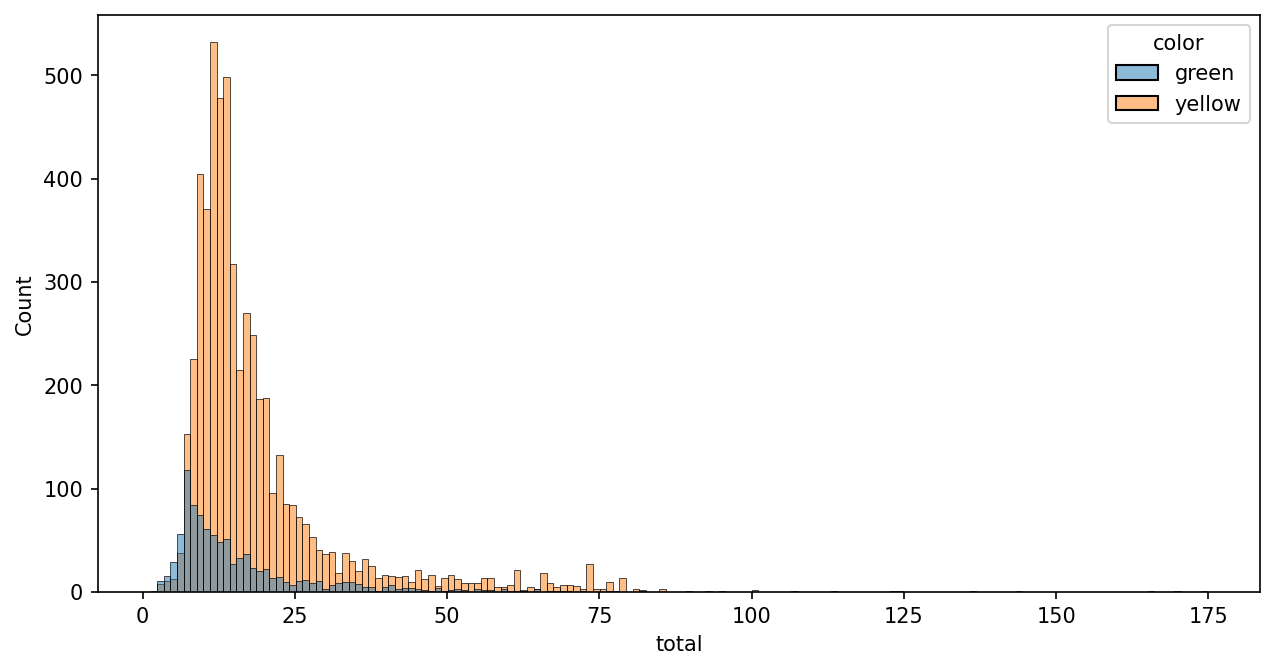

In [25]:
# будуємо гістограми через seaborn
    
plt.figure(figsize=(10, 5), dpi=150)

sns.histplot(
    data=df_taxi_clean.sort_values('color', ascending=False),
    x='total',
    hue='color',
    hue_order=['green', 'yellow'],
    palette={'green': 'C0', 'yellow': 'C1'},
    bins=160,
    alpha=0.5
)

plt.show()

На гістограмі видно, що поїздок на жовтих авто значно більше, ніж на зелених. Для обох кольорів більшість поїздок має невелику суму платежу, а більші значення зустрічаються рідше. Також у жовтих авто частіше трапляються поїздки з вищою сумою платежу, але для точного висновку про те, чи вони в середньому дорожчі, потрібно додатково порівняти середнє або медіанне значення `total` для кожного кольору.

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=17j9hUAo0-65yEuCMHOHUlEW0nRqePOrW)

11.Цікаво, а чи є залежність між дальністю поїздки і розміром чайових? Побудуйте діаграму розсіювання між дальністю поїздки і розміром чайових. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

В очікуваному результаті я надаю графік, який би будувала я. На наведеному прикладі найскладніша частина - це зробити червоною цю лінію тренду (вона побудована з допомогою спеціального типу графіку в seaborn). Аби вказати колір лінії в тому типу графіку треба зазначити в параметрі `line_kws`, що ми хочемо лінію червоного кольору. Але якщо у вас не буде виходити лінія червоного кольору - нехай буде синього - це не критично :)

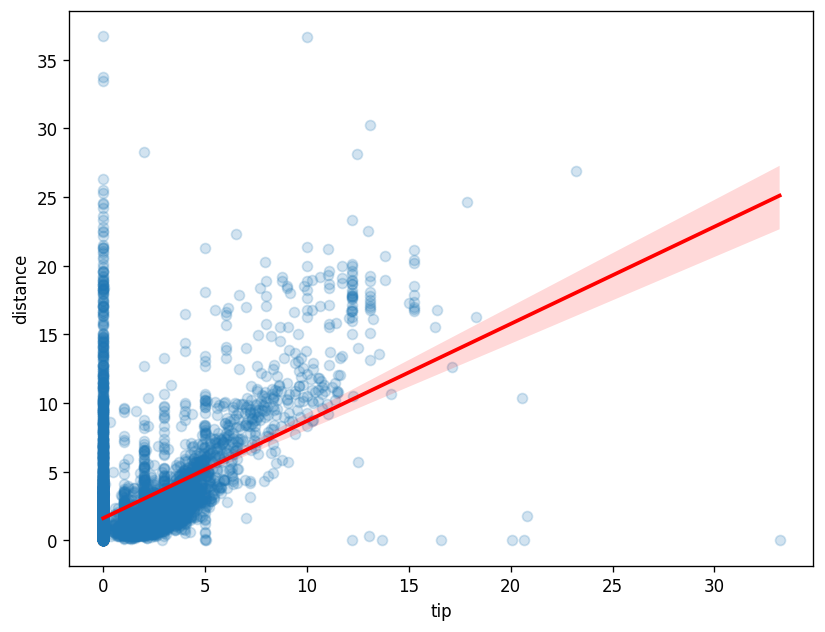

In [26]:
plt.figure(figsize=(8, 6), dpi=120)

sns.regplot(
    data=df_taxi_clean,
    x='tip',
    y='distance',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'red'}
)

plt.xlabel('tip')
plt.ylabel('distance')
plt.show()

На графіку видно позитивну залежність між розміром чайових і дальністю поїздки: загалом зі збільшенням чайових відстань поїздки також зростає. Але точки розміщені досить розсіяно, тому зв’язок не є дуже сильним. Також видно багато поїздок із нульовими чайовими при різній відстані.

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=19PtgLlPTJ1iR_AxcnBDZUw-U3Ulr6Cpy)

12.Дайте відповідь на питання: що означає пряма лінія з точок, паралельна осі, за якою розташована дальність поїздки?

Пряма лінія з точок, паралельна осі `distance`, означає, що для багатьох поїздок значення `tip` дорівнює 0, але при цьому дальність поїздки може бути різною. Тобто це не обов’язково відсутність даних, а ситуація, коли пасажири не залишали чайові.

Також це показує, що розмір чайових залежить не лише від дальності поїздки: навіть для довших поїздок чайові можуть бути нульовими (це чисто бажання пасажира).


13.Побудуйте поденну динаміку чайових по районам, в яких забрали пасажира. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати. Важливо, щоб на одному графіку було 4 лінії (всі райони, крім `NA`), які відображають динаміку чайових, була легенда і були підписи вісей. В очікуваному результаті я надаю графік, який би будувала я.

Дайте відповіді на питання:
- при початку поїздки в якому районі **найнижчий середній розмір** чайових?
- а в поїздках з якого району **найвищий середній розмір** чайових?
- при проїздках з його району розмір чайових найстабільніший (найменше змінюється з дня у день)?

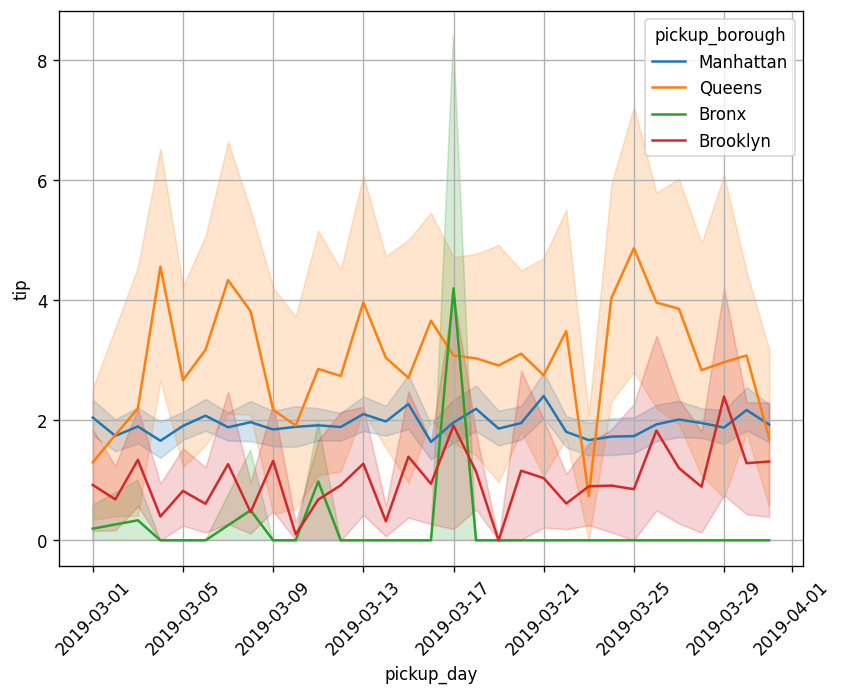

In [27]:
df_tip = df_taxi_clean[df_taxi_clean['pickup_borough'] != 'NA']

plt.figure(figsize=(8, 6), dpi=120)

sns.lineplot(
    data=df_tip,
    x='pickup_day',
    y='tip',
    hue='pickup_borough',
    estimator='mean',
    errorbar=('ci', 95)
)

plt.xlabel('pickup_day')
plt.ylabel('tip')
plt.legend(title='pickup_borough')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [28]:
tip_pivot = df_taxi_clean[
    df_taxi_clean['pickup_borough'] != 'NA'
].pivot_table(
    index='pickup_day',
    columns='pickup_borough',
    values='tip',
    aggfunc='mean'
)

In [29]:
tip_avg = tip_pivot.mean().sort_values()
tip_avg

pickup_borough
Bronx        0.213883
Brooklyn     0.996286
Manhattan    1.930797
Queens       3.006289
dtype: float64

Один з можливих результатів (побудовано з seaborn):

In [30]:
print('Найнижчий середній розмір чайових:', tip_avg.idxmin(), round(tip_avg.min(), 2))
print('Найвищий середній розмір чайових:', tip_avg.idxmax(), round(tip_avg.max(), 2))

Найнижчий середній розмір чайових: Bronx 0.21
Найвищий середній розмір чайових: Queens 3.01


In [31]:
tip_std = tip_pivot.std().sort_values()
tip_std

pickup_borough
Manhattan    0.175172
Brooklyn     0.509089
Bronx        0.793515
Queens       0.946378
dtype: float64

In [32]:
print('Найстабільніший розмір чайових:', tip_std.idxmin(), round(tip_std.min(), 2))

Найстабільніший розмір чайових: Manhattan 0.18


Найнижчий середній розмір чайових спостерігається в районі  Bronx `0.21`.

Найвищий середній розмір чайових - у районі Queens `3.01`.

Найстабільніший розмір чайових має район Manhattan `0.18`, оскільки для нього стандартне відхилення денних середніх чайових є найменшим. Це означає, що середній розмір чайових у цьому районі найменше змінюється з дня у день.

![](https://drive.google.com/uc?export=view&id=1yoEqYwNwyQmTTrkk_Mz6D-ruAvE-Sx8q)

14.Побудуйте box-plot розміру чайових по району (всі райони, крім `NA`) старту поїздки. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

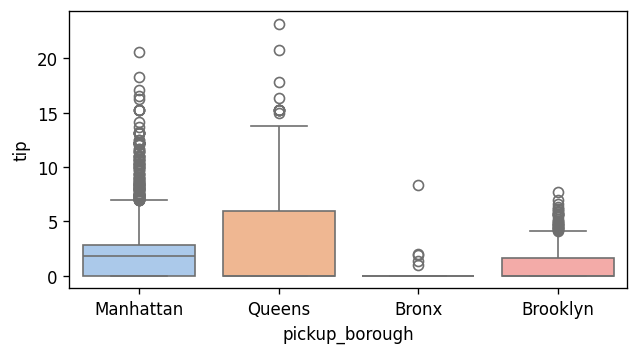

In [33]:
df_tip = df_taxi_clean[df_taxi_clean['pickup_borough'] != 'NA']

plt.figure(figsize=(6, 3), dpi=120)

sns.boxplot(
    data=df_tip,
    x='pickup_borough',
    y='tip',
    hue='pickup_borough',
    palette='pastel',
    legend=False
)

plt.xlabel('pickup_borough')
plt.ylabel('tip')
plt.show()

На box-plot видно, що найвища медіана чайових у Manhattan. 
У Queens найбільший розкид значень, тому там трапляються як низькі, так і високі чайові. 
У Bronx медіана майже нульова, тобто чайові там найчастіше відсутні або дуже низькі.

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=1o6dFRTSj0gLQ_DMWeb7upqvuPNsL0MQc)

15.Творче завдання. Створіть ТРИ інформативних візуалізації, які б допомогли в аналізі цих даних.   

Що вам було б цікаво дізнатись про ці поїздки? Як це можна було б використати при прийнятті рішень бізнесом?
Наприклад, якщо найбільше поїздок в певний час доби, значить, треба стимулювати водіїв працювати в ці години. Якщо найбільше поїздок з певного району - треба тримати там запас авто, які б могли взяти пасажирів і т.д.
Не обмежуйте свою фантазію.

Візуалізації мають бути не тими, на які ми вже побудували вище. Але можна створювати аналогічні, просто з використанням інших полів даних. І описати, що ви бачите з тих візуалізацій.
Без виконання цього завдання ДЗ не приймаєтья. Якщо є питання щодо виконання - пишіть у чат.

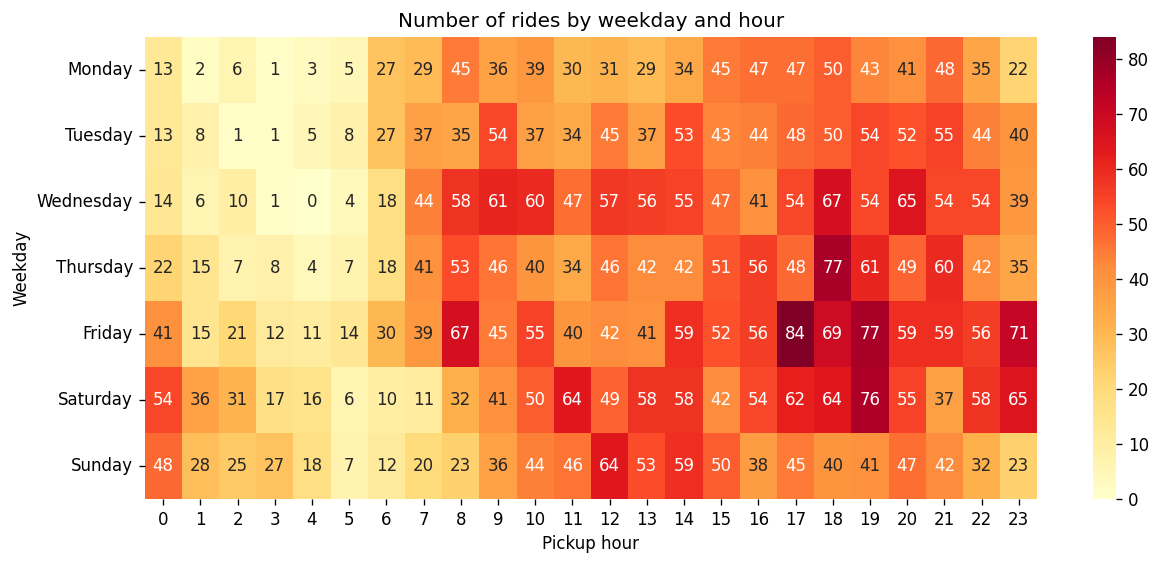

In [34]:
# 1. Heatmap: кількість поїздок за днями та годинами - коли найбільший попит

df_taxi_clean['pickup_hour'] = df_taxi_clean['pickup'].dt.hour
df_taxi_clean['pickup_weekday'] = df_taxi_clean['pickup'].dt.day_name()

days_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

heatmap_data = pd.crosstab(
    df_taxi_clean['pickup_weekday'],
    df_taxi_clean['pickup_hour']
).reindex(days_order)

plt.figure(figsize=(12, 5), dpi=120)

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='d'
)

plt.title('Number of rides by weekday and hour')
plt.xlabel('Pickup hour')
plt.ylabel('Weekday')
plt.show()

**Бізнес-сенс**: визначити періоди пікового попиту та правильно розподілити водіїв.

**Висновок**: у будні попит переважно зростає у другій половині дня та ввечері, що може бути пов’язано з поїздками після роботи. Найвиразніші піки спостерігаються у четвер о 18:00 та у п’ятницю о 17:00–19:00. У вихідні попит розподілений рівномірніше, але залишається високим увечері та в нічні години. Найменше поїздок — приблизно з 2:00 до 6:00.

**Рекомендація**: збільшувати кількість доступних авто у вечірні години буднів, особливо в четвер і п’ятницю, а у вихідні додатково підтримувати достатню кількість водіїв у пізній вечірній та нічний час.

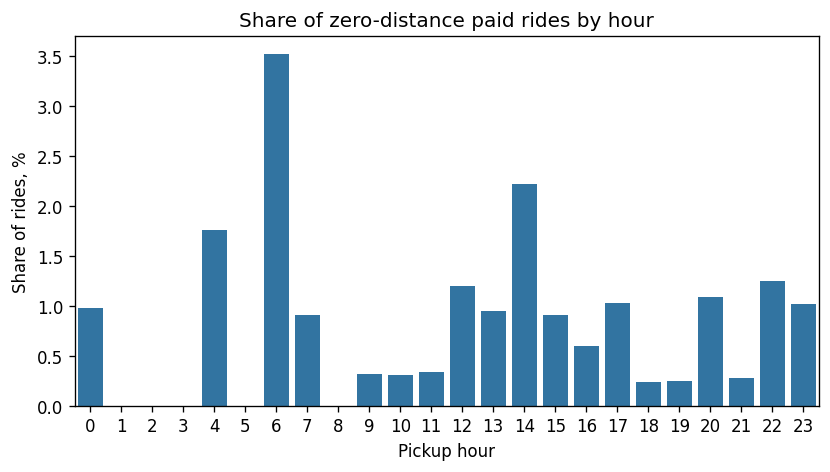

In [35]:
# 2. Частка платних поїздок із нульовою відстанню (аналізуємо поїздки, де distance = 0, але total > 0) - контроль скасувань або помилок

df_taxi_clean['zero_distance_paid'] = (
    (df_taxi_clean['distance'] == 0) &
    (df_taxi_clean['total'] > 0)
)

zero_distance_by_hour = (
    df_taxi_clean.groupby('pickup_hour')['zero_distance_paid']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(8, 4), dpi=120)

sns.barplot(
    data=zero_distance_by_hour,
    x='pickup_hour',
    y='zero_distance_paid'
)

plt.title('Share of zero-distance paid rides by hour')
plt.xlabel('Pickup hour')
plt.ylabel('Share of rides, %')
plt.show()

**Бізнес-сенс:** виявити години з найбільшою часткою аномальних поїздок із нульовою відстанню, але ненульовою оплатою.

**Висновок:** найбільша частка таких поїздок спостерігається о 6:00, далі - о 14:00 та 4:00. Це можуть бути скасування, помилки GPS або некоректна фіксація відстані.

**Рекомендація:** перевірити причини таких випадків у зазначені години та додатково порівняти частку з абсолютною кількістю поїздок, оскільки високий відсоток може бути пов’язаний із малою загальною кількістю поїздок.

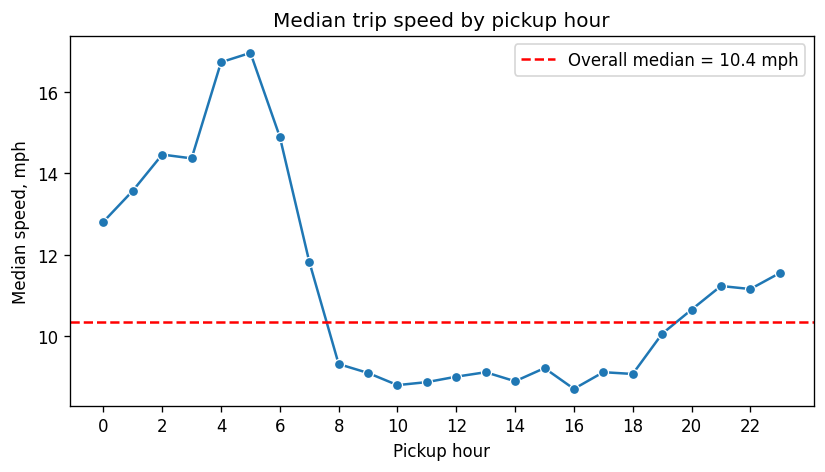

In [36]:
# 3. Медіанна швидкість по годинах, щоб краще побачити можливі затори

df_taxi_clean['duration_min'] = (
    df_taxi_clean['dropoff'] - df_taxi_clean['pickup']
).dt.total_seconds() / 60

df_taxi_clean['speed'] = (
    df_taxi_clean['distance'] /
    (df_taxi_clean['duration_min'] / 60)
)

speed_by_hour = (
    df_taxi_clean[
        (df_taxi_clean['speed'] > 0) &
        (df_taxi_clean['speed'] < 100)
    ]
    .groupby('pickup_hour')['speed']
    .median()
    .reset_index()
)

median_speed_all = speed_by_hour['speed'].median()

plt.figure(figsize=(8, 4), dpi=120)

sns.lineplot(
    data=speed_by_hour,
    x='pickup_hour',
    y='speed',
    marker='o'
)

plt.axhline(
    y=median_speed_all,
    color='red',
    linestyle='--',
    label=f'Overall median = {median_speed_all:.1f} mph'
)

plt.title('Median trip speed by pickup hour')
plt.xlabel('Pickup hour')
plt.ylabel('Median speed, mph')

plt.xticks(range(0, 24, 2))

plt.legend()
plt.show()

**Бізнес-сенс**: години з найнижчою швидкістю можуть свідчити про найбільше завантаження доріг. Це можна враховувати при розрахунку часу прибуття, вартості та розподілі водіїв.

**Висновок**: найвища медіанна швидкість спостерігається близько 4:00–5:00 - приблизно 17 mph. З 8:00 до 18:00 швидкість значно нижча — близько 9 mph, що може свідчити про більшу завантаженість доріг.

**Рекомендація**: враховувати години низької швидкості при розрахунку часу прибуття та вартості поїздки, а також попереджати пасажирів про можливі затримки вдень.

_______________________
**Time spent:** 3 hours

**What I learned:**

* **Очищення даних:** пошук пропущених значень через `isna()`, їх заповнення за допомогою `fillna()` та створення очищеного набору даних.
* **Робота з датою і часом:** перетворення типів через `astype()`, виділення дати, години та дня тижня за допомогою `dt.floor()`, `dt.hour`, `dt.day_name()`.
* **Агрегація даних:** використання `groupby()`, `pivot_table()` і `agg()` для розрахунку сум, середніх значень, кількості поїздок та стандартного відхилення.
* **Візуалізація даних:** робота з бібліотеками `matplotlib` і `seaborn`; побудова гістограм, line plot, scatter plot із лінією тренду, box plot та heatmap.
* **Налаштування графіків:** зміна розміру й якості фігури через `figsize` і `dpi`, додавання заголовків, підписів осей, легенди та сітки.
* **Бізнес-аналіз:** визначення годин пікового попиту, потенційно аномальних поїздок і періодів низької швидкості з подальшим формуванням висновків та рекомендацій.

